# <span style="color:blue"> GALAXY MODEL  gruppo G<span>

## Imports and setup

In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import emcee
import corner
from time import time

%matplotlib widget
plt.close("all")

## Data loading, filtering and unit conversion

In [2]:
# load the data and filter it by only picking stars near the equatorial plane (|b| < 5 deg)
gaia = Table.read("d3.gz")
#mask = abs(gaia['b']) < 5
#gaia = gaia[mask]

# note: we should also filter by parallax error if we dind't do it in the query!!!!

# extract the relevant columns
l = gaia["l"]
b = gaia["b"]
parallax = gaia["parallax"]
parallax_error = gaia["parallax_error"]
radial_velocity = gaia["radial_velocity"]
radial_velocity_error = gaia["radial_velocity_error"]

# print table info
gaia.info

<Table length=349153>
         name          dtype    unit                  description                 n_bad
--------------------- ------- -------- ------------------------------------------ -----
                   ra float64      deg                            Right ascension     0
                  dec float64      deg                                Declination     0
             parallax float64      mas                                   Parallax     0
       parallax_error float64      mas                 Standard error of parallax     0
                 pmra float64 mas / yr Proper motion in right ascension direction     0
                pmdec float64 mas / yr     Proper motion in declination direction     0
      phot_g_mean_mag float32      mag                      G-band mean magnitude     0
     phot_bp_mean_mag float32      mag               Integrated BP mean magnitude   422
     phot_rp_mean_mag float32      mag               Integrated RP mean magnitude   426
      radi

In [3]:
# unit conversion:
#   [velocity] = km/s
#   [distance] = kpc
#   [longitude/latitude] = radians

d_from_sun = 1 / parallax # distance from sun in kpc
l_rad = np.radians(l) # longitude in radians
b_rad = np.radians(b) # latitude in radians

print(f"Number of stars: {len(d_from_sun)}")

Number of stars: 349153


## Model definition and naive comparison

In [12]:
def distance_from_gc(l_rad, b_rad, d_from_sun, R0):
    """Calculate the distance of a star from the galactic center given its longitude, distance from the sun, and the sun's distance from the galactic center.

        Parameters:
        l_rad: longitude in radians
        d_from_sun: distance from the sun in kpc
        R0: distance of the sun from the galactic center in kpc

        Returns:
        distance from the galactic center in kpc
    """
    return np.sqrt(R0**2 + (d_from_sun*np.cos(b_rad))**2 - 2.0*R0*d_from_sun*np.cos(l_rad)*np.cos(b_rad))

def velocity_model(l_rad, b_rad, d_from_sun, R0, V_rot, U0, V0, W0):
    """Calculate the expected radial velocity of a star given its longitude, distance from the sun, and the model parameters.
d_from_sun
        Parameters:
        l_rad: longitude in radians
        d_from_sun: distance from the sun in kpc
        R0: distance of the sun from the galactic center in kpc
        V_rot: rotation velocity of the galaxy in km/s
        U0: solar motion in the radial direction in km/s
        V0: solar motion in the tangential direction in km/s

        Returns:
        expected radial velocity in km/s

    """

    R = distance_from_gc(l_rad,b_rad, d_from_sun, R0)
    
    V_lsr_term = U0 * np.cos(l_rad)*np.cos(b_rad) + V0 * np.sin(l_rad)*np.cos(b_rad) + W0*np.sin(b_rad)
    
    V_rot_term = V_rot*((1.0 / R) - (1.0 / R0))*R0*np.sin(l_rad)*np.cos(b_rad)

    return V_rot_term + V_lsr_term

def model_derivative(l_rad, b_rad, R0, V_rot, distance_from_sun, R, parallax):
    """ Calculate the derivative of the model with respect to the paralllax, needed to propagate the error
    
        Parameters:
        l_rad: longitude in radians
        R0: distance of the sun from the galactic center in kpc
        V_rot: rotation velocity of the galaxy in km/s
        distance_from_sun: distance from the sun in kpc
        R: distance from the galactic center in kpc
        parallax: parallax in mas

        Returns:
        derivative of the model with respect to the parallax in km/s/mas
    """

    dD_dparallax = -1 / parallax**2 # derivative of distance from the sun with respect to parallax
    dR_dD = (distance_from_sun*np.cos(b_rad)**2 - R0*np.cos(l_rad)) / distance_from_gc(l_rad,b_rad,d_from_sun,R0) # derivative of distance from the galactic center with respect to distance from the sun
    dV_dR = -V_rot / R**2 * R0 * np.sin(l_rad) * np.cos(b_rad) # derivative of the model with respect to distance from the galactic center

    return dV_dR * dR_dD * dD_dparallax

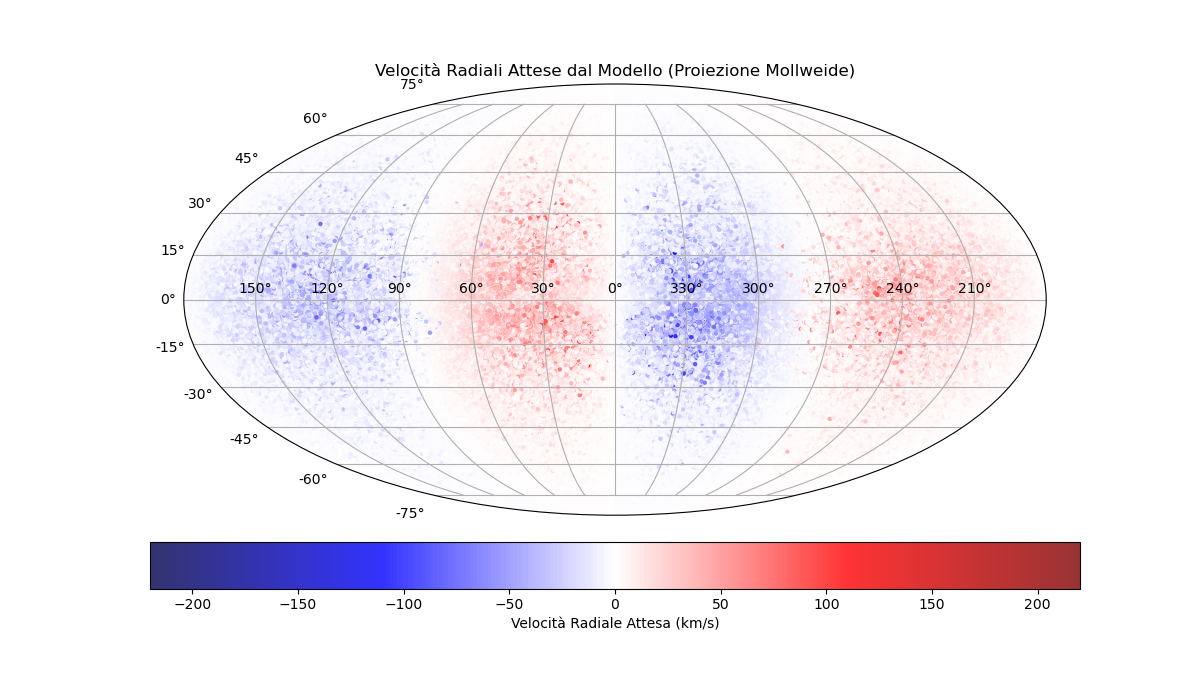

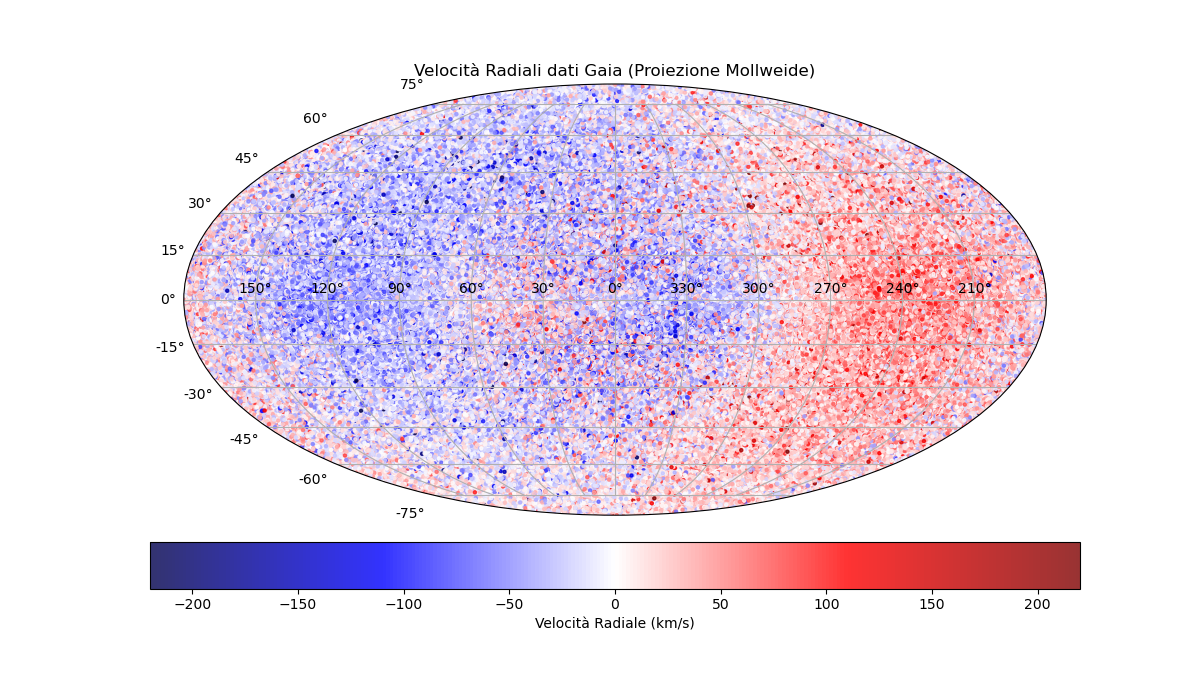

In [13]:
# plot the actual vs expected radial velocities for some initial guess of the parameters
# the lsr term for now is 0

V_rot = 200.0 # km/s
U0 = 0.0 # km/s
V0 = 0.0 # km/s
W0 = 0.0 #km/s
R0 = 8.0 # kpc distance sun from GC

V_rad_exp = velocity_model(l_rad,b_rad,d_from_sun,R0,V_rot,U0,V0,W0)
# 1. Prepariamo le coordinate per la proiezione
# Trasliamo l da [0, 2pi] a [-pi, pi]
l_plot = np.remainder(l_rad + np.pi, 2 * np.pi) - np.pi
b_plot = np.remainder(b_rad + np.pi, 2 * np.pi) - np.pi

# Invertiamo il segno di l per avere l=0 al centro e l che cresce verso sinistra (convenzione standard)
l_plot = -l_plot

# b_rad è già nel range [-pi/2, pi/2], quindi è pronto

fig = plt.figure(figsize=(12, 7))
# Creiamo un subplot con proiezione 'mollweide' (o 'aitoff')
ax = fig.add_subplot(111, projection='mollweide')
sc = ax.scatter(l_plot, b_plot, c=radial_velocity, cmap='seismic', s=5, alpha=0.8, vmin=-220, vmax=220)
plt.colorbar(sc, label='Velocità Radiale (km/s)', orientation='horizontal', pad=0.05)
ax.grid(True)
ax.set_title("Velocità Radiali dati Gaia (Proiezione Mollweide)")
# Opzionale: aggiungiamo le etichette per i gradi (Matplotlib usa i radianti di default)
ax.set_xticklabels(['150°', '120°', '90°', '60°', '30°', '0°', '330°', '300°', '270°', '240°', '210°'])

#PLOT MODEL

fig2 = plt.figure(figsize=(12, 7))
ax2 = fig2.add_subplot(111, projection='mollweide')
sc2 = ax2.scatter(l_plot, b_plot, c=V_rad_exp, cmap='seismic', s=5, alpha=0.8, vmin=-220, vmax=220)
plt.colorbar(sc2, label='Velocità Radiale Attesa (km/s)', orientation='horizontal', pad=0.05)
ax2.grid(True)
ax2.set_title("Velocità Radiali Attese dal Modello (Proiezione Mollweide)")
ax2.set_xticklabels(['150°', '120°', '90°', '60°', '30°', '0°', '330°', '300°', '270°', '240°', '210°'])

plt.show()

## Statistical analysis

### Probability

In [16]:
# vectorized version of log_probability for emcee with vectorize=True, which allows us to evaluate the log-probability for multiple sets of parameters at once (one for each walker)

def log_likelihood_vect(theta, V_rad, l, b, d, v_rad_error, parallax_error, V_rot_fixed):
    # theta is formatted as ((V_rot1, U01, V01), (V_rot2, U02, V02), ...)
    V_rot = theta[:, 0][:, np.newaxis]   # (nwalkers, 1)
    U0    = theta[:, 1][:, np.newaxis]
    V0    = theta[:, 2][:, np.newaxis]
    W0    = theta[:, 3][:, np.newaxis]

    R = distance_from_gc(l, b, d, R0)

    # V_rad as function of V_rot (and l)
    model =  velocity_model(l, b, d, R0, V_rot, U0, V0, W0)

    sigma2 = v_rad_error**2 + (model_derivative(l, b, R0, V_rot_fixed, d, R, parallax) * parallax_error)**2

    # return value should be an array of log-likelihoods, one for each set of parameters in theta
    return -np.sum(0.5 * np.log(2.0 * np.pi * sigma2) + 0.5 * (V_rad - model)**2 / sigma2, axis=1)

def log_prior_vect(theta):
    V_rot = theta[:, 0]
    U0 = theta[:, 1]
    V0 = theta[:, 2]
    W0 = theta[:, 3]

    # set the prior to be uniform, but set some bounds on the parameters

    mask = (0.0 < V_rot) & (V_rot < 400.0) & (-50.0 < U0) & (U0 < 50.0) & (-50.0 < V0) & (V0 < 50.0) & (-50.0 < W0) & (W0 < 50.0)

    log_pri = np.full(theta.shape[0], -np.inf)
    log_pri[mask] = 0.0

    return log_pri

def log_probability_vect(theta, V_rad, l, b, d, v_rad_error, parallax_error, V_rot_fixed):
    log_pri = log_prior_vect(theta)
    log_prob = np.full(theta.shape[0], -np.inf)

    valid = np.isfinite(log_pri)

    if np.any(valid):
        log_prob[valid] = log_likelihood_vect(
            theta[valid], V_rad, l, b, d, v_rad_error, parallax_error, V_rot_fixed
        ) + log_pri[valid]
        
    return log_prob

### Max likelyhood

We first do a short run to get a reasonable estimate for a v_rot to use for error propagation. This run uses the initial guess for this purpose.
We extract this first estimate for V_rot as an average over the last samples of the chain (to exclude autocorrelated values)

100%|██████████| 100/100 [02:02<00:00,  1.22s/it]

(2880, 4)
V_rot guess: 185.0349400867947


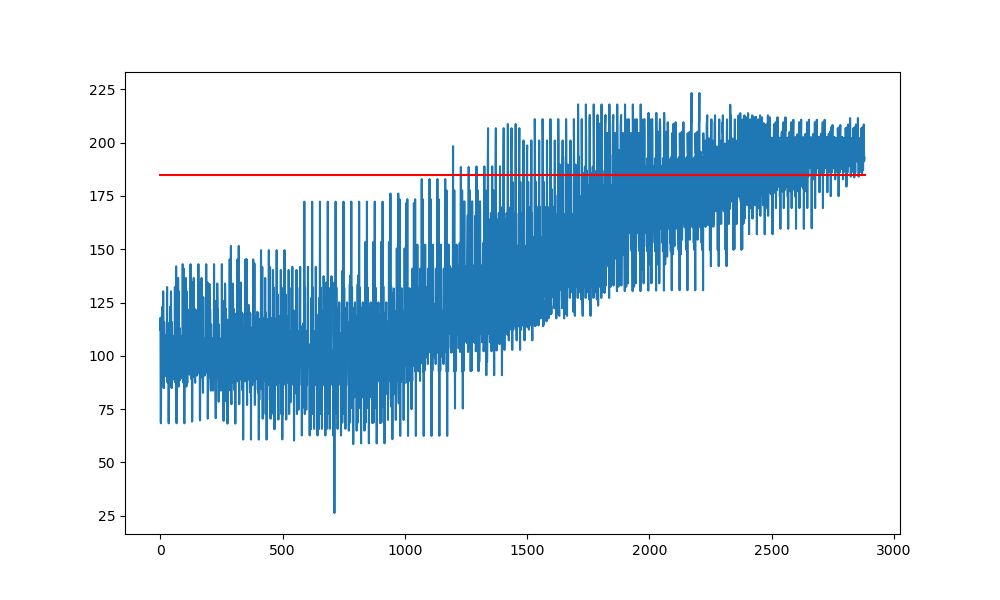

In [ ]:
# initial guess for the parameters
# we set some reasonable start values (well inside the prior bounds), then add some random noise to create the initial positions of the walkers
p0 = [100.0, 10, 10, 10] # initial guess for the parameters
pos = p0 + np.array([10.0, 5.0, 5.0, 5.0]) * np.random.randn(32, 4)   # 32 walkers, 4 parameters (V_rot, U0, V0, W0)

# number of walkers and dimensions can be inferred from the shape of the pos array
nwal, dim = pos.shape
num_iters_prev = 200    # used for the initial guess for V_rot
num_iters = 3000    # min 3000 step for autocorrelation

sampler_prev = emcee.EnsembleSampler(nwal, dim, log_probability_vect, args=(radial_velocity, l_rad, b_rad, d_from_sun, radial_velocity_error, parallax_error, p0[0]), vectorize=True)
sampler_prev.run_mcmc(pos, num_iters_prev, progress=True)

prev_samples = sampler_prev.get_chain(discard=10, thin=1, flat=True)

v_rot_prev_samples = prev_samples[:, 0]
v_rot_prev_samples = v_rot_prev_samples[-1000:]
v_rot_guess = np.mean(v_rot_prev_samples)

print(prev_samples.shape)
print(f"V_rot guess: {v_rot_guess}")

plt.figure(figsize=(10, 6))
plt.plot(prev_samples[:, 0], zorder=1)

plt.plot([0, len(prev_samples)], [v_rot_guess, v_rot_guess], label='V_rot guess', zorder=2, color='red')

plt.show()

In [20]:
sampler = emcee.EnsembleSampler(nwal, dim, log_probability_vect, args=(radial_velocity, l_rad, b_rad, d_from_sun, radial_velocity_error, parallax_error, v_rot_guess), vectorize=True)
sampler.run_mcmc(pos, num_iters, progress=True)

  0%|          | 10/3000 [00:12<1:03:29,  1.27s/it]Traceback (most recent call last):
  File "/home/enrico/anaconda3/lib/python3.11/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_743598/3430860368.py", line 42, in log_probability_vect
    log_prob[valid] = log_likelihood_vect(
                      ^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_743598/3430860368.py", line 18, in log_likelihood_vect
    return -np.sum(0.5 * np.log(2.0 * np.pi * sigma2) + 0.5 * (V_rad - model)**2 / sigma2, axis=1)
                                                              ~~~~~~~~~~~~~~~^^~
  File "/home/enrico/anaconda3/lib/python3.11/site-packages/numpy/ma/core.py", line 4307, in __pow__
    return power(self, other)
           ^^^^^^^^^^^^^^^^^^
  File "/home/enrico/anaconda3/lib/python3.11/site-packages/numpy/ma/core.py", line 6980, in power
    result = np.where(m, fa, umat

emcee: Exception while calling your likelihood function:
  params: [[118.01189702   2.83326531   8.91162489   4.4912826 ]
 [ 68.3645525  -18.2018572  -17.54602374   6.41908048]
 [ 96.67245943 -15.85990544   2.58204012  12.4244127 ]
 [103.49158168   8.63158697   0.18243432  18.33033142]
 [ 93.40520132   8.99453523   5.42334433  14.69881328]
 [116.52124777   9.33165915  -0.86684116   0.71305186]
 [140.93634694  -7.54227599   8.63831996 -24.93611714]
 [111.72916652   6.20294074  -9.2719611   15.50637713]
 [ 84.85292925 -10.57672365 -23.96134174  18.45821313]
 [106.04086817   6.9014561    8.34712069   7.13176018]
 [ 93.67902349 -10.6354247    2.739263     3.3017533 ]
 [ 90.45947943   4.45785602 -12.02654289  19.49019202]
 [109.82316385  -3.19253475   5.96605928  -7.9287893 ]
 [102.38271125  10.9902978    6.04233237  11.70756267]
 [ 96.98989403   7.13414531  -0.60144993  14.87168152]
 [ 88.30295607  13.81334343  -0.65494099  15.32537716]]
  args: (<MaskedColumn name='radial_velocity' dtype=

KeyboardInterrupt: 

## Post processing

### Burn in

In [19]:
tau = sampler.get_autocorr_time()
burn_in = int(2 * np.max(tau))
thin = int(0.5 * np.min(tau))

#burn_in = 10
#thin = 1

samples = sampler.get_chain(discard=burn_in, thin=thin, flat=True)

print(f"Number of samples: {samples.shape[0]}")
print(f"Mean acceptance fraction: {sampler.acceptance_fraction.mean():.3f}")
print(f"Autocorrelation time: {tau}")

NameError: name 'sampler' is not defined

In [12]:
# dump the samples to a file for later use
np.save(f"samples/gaia_mcmc_samples_{time()}.npy", samples)

In [ ]:
V_rot_mcmc, U0_mcmc, V0_mcmc, W0_mcmc = np.percentile(samples, [16, 50, 84], axis=0).T

# extract the best-fit parameters (the median of the posterior distribution) as medians
V_rot_best = V_rot_mcmc[1]
U0_best = U0_mcmc[1]
V0_best = V0_mcmc[1]
W0_best = W0_mcmc[1]

# extract the uncertainties as the 16th and 84th percentiles (2/3s confidence interval)
V_rot_uncertainty = np.abs(V_rot_mcmc[0] - V_rot_mcmc[2])
U0_uncertainty = np.abs(U0_mcmc[0] - U0_mcmc[2])
V0_uncertainty = np.abs(V0_mcmc[0] - V0_mcmc[2])
W0_uncertainty = np.abs(W0_mcmc[0] - W0_mcmc[2])

# print the best values
print(f"Best-fit V_rot: {V_rot_best:.2f} km/s ± {V_rot_uncertainty:.2f} km/s")
print(f"Best-fit U0: {U0_best:.2f} ± {U0_uncertainty:.2f}")
print(f"Best-fit V0: {V0_best:.2f} ± {V0_uncertainty:.2f}")
print(f"Best-fit W0: {W0_best:.2f} ± {W0_uncertainty:.2f}")

Best-fit V_rot: 221.79 km/s ± 0.15 km/s
Best-fit U0: -10.32 ± 0.01
Best-fit V0: -21.40 ± 0.01


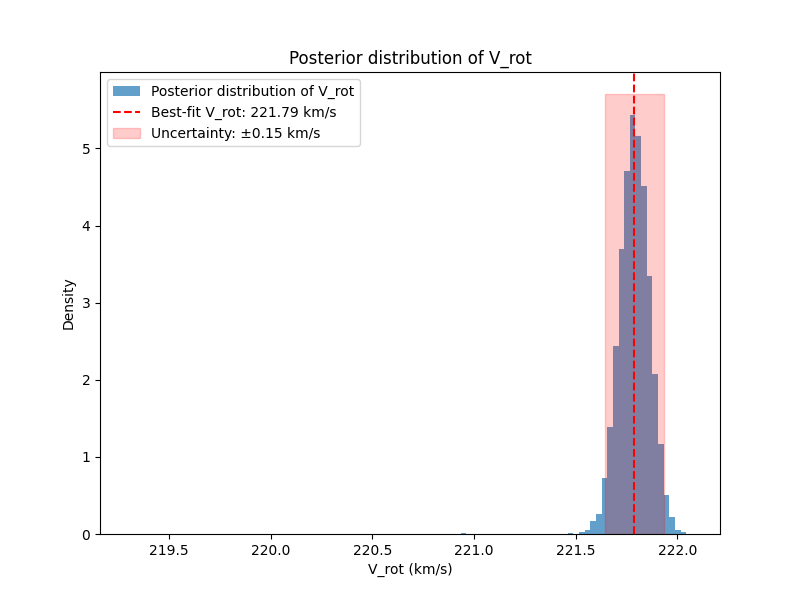

In [14]:
# hist of v_rot computed values

plt.figure(figsize=(8, 6))
plt.hist(samples[:, 0], bins=100, density=True, alpha=0.7, label="Posterior distribution of V_rot")

# plot the best-fit value as a vertical line
plt.axvline(V_rot_best, color='r', linestyle='--', label=f"Best-fit V_rot: {V_rot_best:.2f} km/s")

# plot the uncertainty as a shaded region
plt.fill_betweenx([0, plt.gca().get_ylim()[1]], V_rot_best - V_rot_uncertainty, V_rot_best + V_rot_uncertainty, color='r', alpha=0.2, label=f"Uncertainty: ±{V_rot_uncertainty:.2f} km/s")

plt.legend()
plt.xlabel("V_rot (km/s)")
plt.ylabel("Density")
plt.title("Posterior distribution of V_rot")
plt.show()

### Corner plot

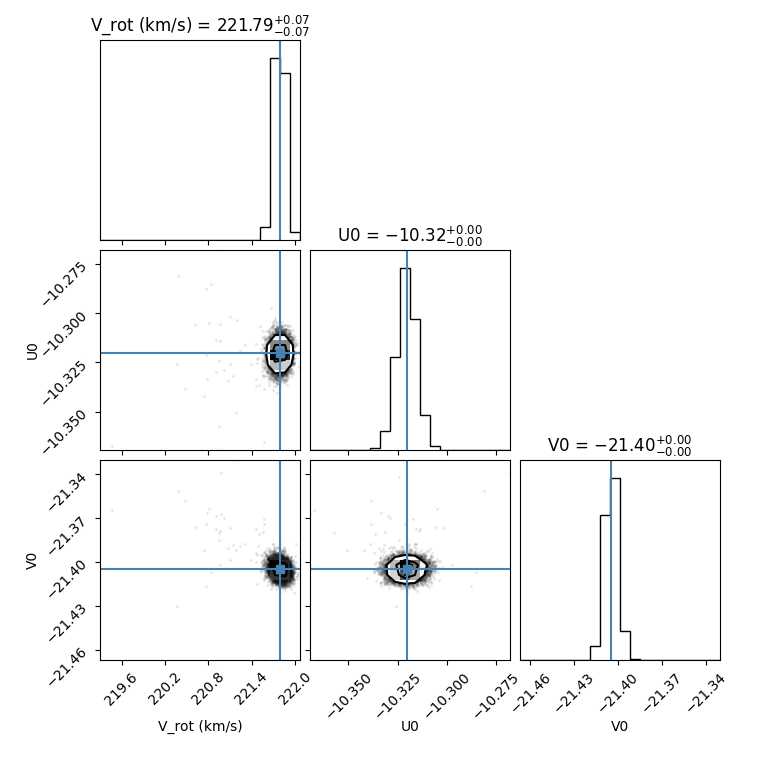

In [ ]:
fig = corner.corner(
    samples, 
    labels=["V_rot (km/s)", "U0", "V0", "W0"], 
    truths=[V_rot_best, U0_best, V0_best, W0_best], 
    show_titles=True
)

### Trace plot

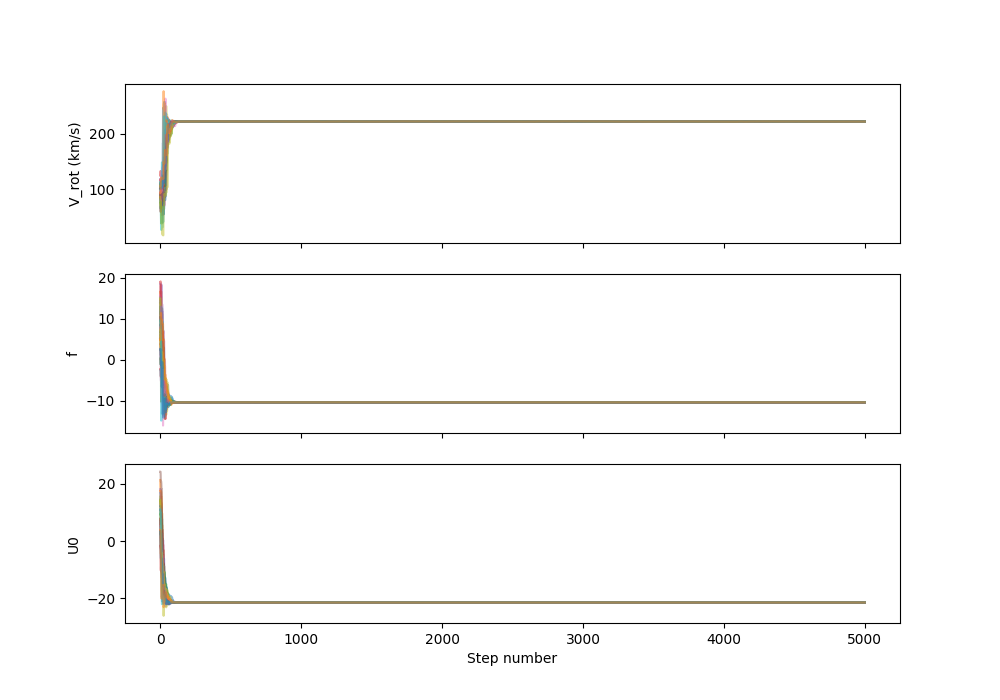

In [ ]:
# trace plot to check for convergence for both parameters
fig, axes = plt.subplots(dim, figsize=(10, 7), sharex=True)
samples_chain = sampler.get_chain()

parameter_labels = ["V_rot (km/s)", "U0 (km/s)", "V0 (km/s)", "W0 (km/s)"]

for i in range(dim):
    ax = axes[i]
    for walker in range(nwal):
        ax.plot(samples_chain[:, walker, i], alpha=0.5)
    ax.set_ylabel(f"{parameter_labels[i]}")

axes[-1].set_xlabel("Step number")

plt.show()

### Comparison

In [ ]:
# plot the actual vs expected radial velocities for some initial guess of the parameters
# the lsr term for now is 0

V_rot = V_rot_best # km/s
U0 = U0_best # km/s
V0 = V0_best # km/s
W0 = W0_best #km/s 

V_rad_exp = velocity_model(l_rad,b_rad,d_from_sun,R0,V_rot,U0,V0,W0)
# 1. Prepariamo le coordinate per la proiezione
# Trasliamo l da [0, 2pi] a [-pi, pi]
l_plot = np.remainder(l_rad + np.pi, 2 * np.pi) - np.pi
b_plot = np.remainder(b_rad + np.pi, 2 * np.pi) - np.pi

# Invertiamo il segno di l per avere l=0 al centro e l che cresce verso sinistra (convenzione standard)
l_plot = -l_plot

# b_rad è già nel range [-pi/2, pi/2], quindi è pronto

fig = plt.figure(figsize=(12, 7))
# Creiamo un subplot con proiezione 'mollweide' (o 'aitoff')
ax = fig.add_subplot(111, projection='mollweide')
sc = ax.scatter(l_plot, b_plot, c=radial_velocity, cmap='seismic', s=5, alpha=0.8, vmin=-220, vmax=220)
plt.colorbar(sc, label='Velocità Radiale (km/s)', orientation='horizontal', pad=0.05)
ax.grid(True)
ax.set_title("Velocità Radiali dati Gaia (Proiezione Mollweide)")
# Opzionale: aggiungiamo le etichette per i gradi (Matplotlib usa i radianti di default)
ax.set_xticklabels(['150°', '120°', '90°', '60°', '30°', '0°', '330°', '300°', '270°', '240°', '210°'])

#PLOT MODEL

fig2 = plt.figure(figsize=(12, 7))
ax2 = fig2.add_subplot(111, projection='mollweide')
sc2 = ax2.scatter(l_plot, b_plot, c=V_rad_exp, cmap='seismic', s=5, alpha=0.8, vmin=-220, vmax=220)
plt.colorbar(sc2, label='Velocità Radiale Attesa (km/s)', orientation='horizontal', pad=0.05)
ax2.grid(True)
ax2.set_title("Velocità Radiali Attese dal Modello (Proiezione Mollweide)")
ax2.set_xticklabels(['150°', '120°', '90°', '60°', '30°', '0°', '330°', '300°', '270°', '240°', '210°'])

plt.show()